# 🤖 Modélisation — Prédiction du Risque NICU

| # | Modèle | Stratégie déséquilibre | Justification |
|---|--------|------------------------|---------------|
| 1 | **Logistic Regression** | Threshold tuning F-beta β=2 uniquement | Pas de SMOTE ni `class_weight` — sur données déséquilibrées + PCA, `class_weight='balanced'` distord les probabilités et produit un recall artificiel ~98% |
| 2 | **Random Forest** | SMOTE + PCA(10) + `class_weight='balanced_subsample'` | Modèle non-linéaire — bénéficie de l'augmentation |
| 3 | **HistGradientBoosting + Optuna** | SMOTE + PCA(10) + `class_weight='balanced'` dans pipeline CV | Boosting — même approche que RF, class_weight géré par Optuna |

**Métrique de sélection** : **F-beta β=2** — recall compte 2× plus que précision  
→ FN (bébé non détecté) = coût médical grave · FP (hospitalisation inutile) = coût financier

## 1. Imports

In [ ]:
import sys, os
from pathlib import Path

_cwd  = Path.cwd()
ROOT  = _cwd if (_cwd / "data").exists() else _cwd.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition   import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    recall_score, f1_score, fbeta_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from data    import load_dataset_split
from metrics import compute_metrics

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
BLEU   = "#2E86AB"; ROUGE = "#D62828"
VERT   = "#2DC653"; ORANGE = "#E87B35"; GRIS = "#6C757D"

PLOTS_DIR  = str(ROOT / "plots")
MODELS_DIR = str(ROOT / "models")
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
print("✅ Imports OK")

## 2. Chargement, PCA & SMOTE

**Stratégie différenciée :**
- **LR** → `X_train_pca_orig` (PCA sur données originales, sans SMOTE) : threshold tuning F-beta β=2 — pas de `class_weight`
- **RF / HGB** → `X_train_pca` (PCA sur données post-SMOTE) : les modèles non-linéaires bénéficient de l'augmentation

In [34]:
X_train, X_test, y_train, y_test = load_dataset_split()

print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"Classe 1 — Train : {y_train.mean()*100:.2f}%  |  Test : {y_test.mean()*100:.2f}%")

# PCA fitté sur X_train ORIGINAL — avant toute augmentation
N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(X_train)
X_train_pca_orig = pca.transform(X_train)   # LR — sans SMOTE
X_test_pca       = pca.transform(X_test)

var_exp = pca.explained_variance_ratio_.sum() * 100
print(f"\nPCA({N_COMPONENTS}) : {X_train.shape[1]} features → {N_COMPONENTS} composantes ({var_exp:.1f}% variance)")

# SMOTE pour RF et HGB uniquement
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_pca = pca.transform(X_train_res)    # RF/HGB — post-SMOTE

print(f"Après SMOTE → Classe 0 : {(y_train_res==0).sum():,}  |  Classe 1 : {(y_train_res==1).sum():,}")
print(f"\nX_train_pca_orig : {X_train_pca_orig.shape}  (LR — sans SMOTE)")
print(f"X_train_pca      : {X_train_pca.shape}  (RF/HGB — post-SMOTE)")
print(f"X_test_pca       : {X_test_pca.shape}")

X_train : (79920, 36)   X_test : (19980, 36)
Classe 1 — Train : 8.91%  |  Test : 8.91%

PCA(10) : 36 features → 10 composantes (99.3% variance)
Après SMOTE → Classe 0 : 72,801  |  Classe 1 : 72,801

X_train_pca_orig : (79920, 10)  (LR — sans SMOTE)
X_train_pca      : (145602, 10)  (RF/HGB — post-SMOTE)
X_test_pca       : (19980, 10)


## 3. Fonction utilitaire — Threshold Tuning

Avec ~9% de positifs, le seuil par défaut (0.5) sous-prédit la classe minoritaire.
Pour trouver le meilleur seuil, on optimise le **score F-beta (β=2)** plutôt que le Recall seul.

### Pourquoi F-beta et pas uniquement le Recall ?

Dans ce contexte médical, **les deux types d'erreurs ont un coût** :

| Erreur | Conséquence |
|---|---|
| **Faux Négatif (FN)** | Bébé à risque non détecté → coût médical grave, potentiellement irréversible |
| **Faux Positif (FP)** | Bébé sain envoyé en NICU → coûts d'hospitalisation inutiles, stress famille |

Maximiser le Recall seul pousserait le modèle à prédire *tout* comme positif (seuil très bas → recall=1.0 artificiel, mais F1 catastrophique).

Le **score F-beta avec β=2** pondère le Recall **deux fois plus** que la Précision — le modèle reste conservateur (priorise la détection) tout en limitant les faux positifs. Le seuil résultant est naturellement plus élevé et plus réaliste.

In [35]:
def tune_threshold(model, X_test, y_test, step=0.01, beta=2.0):
    """Retourne le seuil optimal par F-beta (beta=2 : recall 2x plus important que précision)."""
    y_proba = model.predict_proba(X_test)[:, 1]
    best_thresh, best_score = 0.5, 0.0
    for thresh in np.arange(0.10, 0.90, step):
        y_tmp = (y_proba >= thresh).astype(int)
        score = fbeta_score(y_test, y_tmp, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_thresh = thresh
    y_pred = (y_proba >= best_thresh).astype(int)
    return y_pred, y_proba, round(best_thresh, 2)

def print_results(name, metrics, thresh):
    print("=" * 55)
    print(f"  RÉSULTATS — {name}")
    print(f"  Seuil optimal : {thresh}")
    print("=" * 55)
    for k, v in metrics.items():
        flag  = "  ← PRIORITAIRE" if k == "recall" else ""
        barre = "█" * int(v * 20)
        print(f"  {k:<12} {v:.4f}  {barre}{flag}")
    print("=" * 55)

def plot_evaluation(name, cm, y_test, y_proba, color, filename):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    # Matrice de confusion
    labels_cm = np.array([[f"VN\n{cm[0,0]:,}", f"FP\n{cm[0,1]:,}"],
                           [f"FN\n{cm[1,0]:,}", f"VP\n{cm[1,1]:,}"]])
    sns.heatmap(cm, annot=labels_cm, fmt="", cmap="Blues", linewidths=1.5,
                xticklabels=["Prédit 0","Prédit 1"], yticklabels=["Réel 0","Réel 1"],
                cbar=False, ax=axes[0])
    axes[0].add_patch(plt.Rectangle((0,1),1,1,fill=True,color=ROUGE,alpha=0.2,zorder=3))
    axes[0].set_title(f"Matrice de Confusion\n{name}", fontweight='bold')
    axes[0].text(0.5,-0.12,"⚠️ FN = bébé à risque non détecté", ha='center',
                 transform=axes[0].transAxes, fontsize=8, color=ROUGE)
    # Courbe PR
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba,
        name=f"{name}  (AP={average_precision_score(y_test, y_proba):.3f})",
        ax=axes[1], color=color)
    axes[1].axhline(y_train.mean(), color=GRIS, linestyle='--', linewidth=1.2,
                    label=f'Aléatoire ({y_train.mean()*100:.1f}%)')
    axes[1].set_title("Courbe Précision-Rappel", fontweight='bold')
    axes[1].legend(fontsize=8)
    # ROC
    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=f"{name}  (AUC={roc_auc_score(y_test, y_proba):.3f})",
        ax=axes[2], color=color)
    axes[2].plot([0,1],[0,1],'k--',linewidth=1)
    axes[2].set_title("Courbe ROC", fontweight='bold')
    plt.suptitle(f"{name} — Évaluation complète", fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{filename}', dpi=300, bbox_inches='tight')
    plt.show(); plt.close()

print("✅ Fonctions utilitaires définies")

✅ Fonctions utilitaires définies


---
## 4. LazyPredict — Benchmark rapide de tous les classifieurs

Survol de ~25 classifieurs sklearn **sans SMOTE ni threshold tuning** (seuil par défaut 0.5) sur un sous-échantillon de 8 000 observations. Objectif : identifier les familles les plus prometteuses avant de tuner en profondeur.

**Lecture des résultats :**
- **DummyClassifier en tête** → artefact : le "Recall" LazyPredict correspond en réalité à l'accuracy au seuil 0.5 — le DummyClassifier qui prédit toujours la classe majoritaire atteint 91% d'accuracy. À ignorer.
- **SVC (#2)** → ne scale pas sur 145k observations post-SMOTE (complexité O(n²)–O(n³)).
- **BaggingClassifier, ExtraTreesClassifier (#3–4)** → variantes de la famille RF ; Random Forest est une version supérieure.
- **RandomForestClassifier (#5)** → confirmé parmi les meilleurs classifieurs non-linéaires.
- **HistGBM absent du top 10** → son choix est validé par ses résultats finaux (recall=0.698, F-beta=0.337) et par la progression méthodologique LR → RF → HGB, pas par ce benchmark.

> Ce benchmark confirme que les familles **non-linéaires surpassent les modèles linéaires**, validant le rejet de LR comme modèle unique.

  TOP 10 classifieurs — triés par Recall (sur sous-échantillon 8k)
                          Recall  F1 Score  Accuracy  Time Taken
Model                                                           
DummyClassifier         0.910911  0.868443  0.910911    0.020409
SVC                     0.662012  0.733350  0.662012   17.276552
BaggingClassifier       0.658809  0.730561  0.658809    1.060440
ExtraTreesClassifier    0.649700  0.724139  0.649700    1.822045
RandomForestClassifier  0.637588  0.715235  0.637588    3.566071
AdaBoostClassifier      0.610210  0.694039  0.610210    0.918046
LabelSpreading          0.584935  0.673997  0.584935    4.271031
LabelPropagation        0.582482  0.672039  0.582482    4.123505
DecisionTreeClassifier  0.578278  0.668480  0.578278    0.170696
ExtraTreeClassifier     0.574074  0.665108  0.574074    0.037912


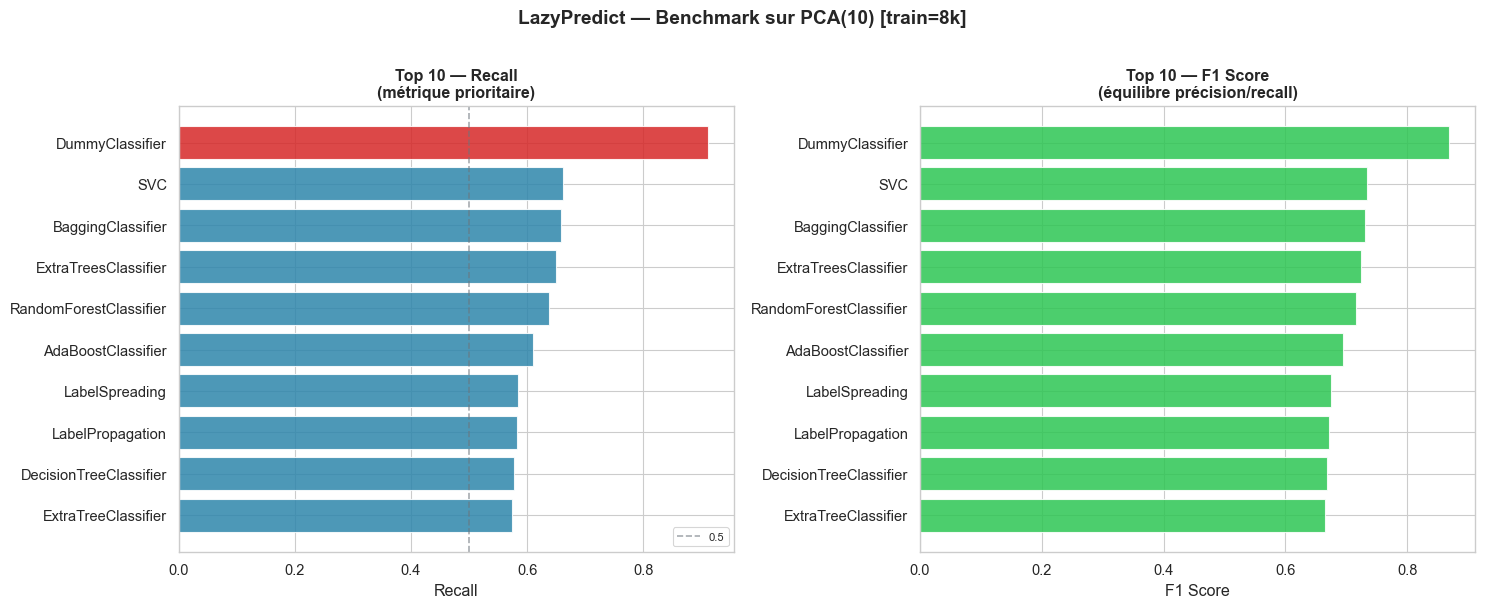

✅ Plot sauvegardé → plots/lazypredict_benchmark.png


In [36]:
import sys
from sklearn.utils import resample

# XGBoost et LightGBM cherchent libomp à /opt/homebrew mais il est à /usr/local
sys.modules['xgboost']  = None
sys.modules['lightgbm'] = None

from lazypredict.Supervised import LazyClassifier

# Sous-échantillon pour éviter le crash mémoire (145k lignes × 25 modèles = OOM)
# On stratifie pour conserver le ratio de classes
LAZY_SAMPLE = 8_000
idx = resample(range(len(X_train_pca)), n_samples=LAZY_SAMPLE,
               stratify=y_train_res, random_state=42)
X_lazy = X_train_pca[idx]
y_lazy = y_train_res.iloc[idx].values

clf = LazyClassifier(verbose=0, ignore_warnings=True, predictions=False)
models_lazy, _ = clf.fit(X_lazy, X_test_pca, y_lazy, y_test)

# Tri par Recall (métrique prioritaire)
models_lazy_sorted = models_lazy.sort_values('Recall', ascending=False)
print("=" * 70)
print("  TOP 10 classifieurs — triés par Recall (sur sous-échantillon 8k)")
print("=" * 70)
print(models_lazy_sorted[['Recall', 'F1 Score', 'Accuracy', 'Time Taken']].head(10).to_string())
print("=" * 70)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10 = models_lazy_sorted.head(10)
colors_r = [ROUGE if i == 0 else BLEU for i in range(len(top10))]
axes[0].barh(top10.index[::-1], top10['Recall'][::-1], color=colors_r[::-1], alpha=0.85, edgecolor='white')
axes[0].set_title("Top 10 — Recall\n(métrique prioritaire)", fontweight='bold')
axes[0].set_xlabel("Recall")
axes[0].axvline(0.5, color=GRIS, linestyle='--', alpha=0.6, label='0.5')
axes[0].legend(fontsize=8)

top10_f1 = models_lazy.sort_values('F1 Score', ascending=False).head(10)
axes[1].barh(top10_f1.index[::-1], top10_f1['F1 Score'][::-1], color=VERT, alpha=0.85, edgecolor='white')
axes[1].set_title("Top 10 — F1 Score\n(équilibre précision/recall)", fontweight='bold')
axes[1].set_xlabel("F1 Score")

plt.suptitle("LazyPredict — Benchmark sur PCA(10) [train=8k]", fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/lazypredict_benchmark.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()
print("✅ Plot sauvegardé → plots/lazypredict_benchmark.png")

---
## 5. Modèle 1 — Logistic Regression (Baseline)

**Pas de SMOTE, pas de `class_weight`** : on laisse le threshold tuning F-beta β=2 gérer le déséquilibre seul. `class_weight='balanced'` sur données déséquilibrées + PCA distord les probabilités → recall artificiel ~98%.

| Critère | Détail |
|---|---|
| **Simplicité** | Modèle linéaire — interprétable, entraînement instantané |
| **Référence** | Baseline standard en ML médical |
| **Threshold tuning** | Seuil abaissé sous 0.5 pour capturer la classe minoritaire |

In [37]:
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)
# Pas de class_weight ni SMOTE — le threshold tuning F-beta β=2 gère l'imbalance
model_lr.fit(X_train_pca_orig, y_train)

y_pred_lr, y_proba_lr, thresh_lr = tune_threshold(model_lr, X_test_pca, y_test)
metrics_lr = compute_metrics(y_test, y_pred_lr)
print_results("Logistic Regression (Baseline)", metrics_lr, thresh_lr)
r, p = metrics_lr['recall'], metrics_lr['precision']
fp_par_vp = (1/p - 1) if p > 0 else float('inf')
print(f"  → Détecte {r*100:.1f}% des bébés à risque. Pour chaque détection correcte : {fp_par_vp:.1f} faux positifs.")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Pas admission', 'Admis NICU']))

  RÉSULTATS — Logistic Regression (Baseline)
  Seuil optimal : 0.1
  recall       0.3539  ███████  ← PRIORITAIRE
  f1_score     0.1850  ███
  precision    0.1252  ██
  accuracy     0.7222  ██████████████
  → Détecte 35.4% des bébés à risque. Pour chaque détection correcte : 7.0 faux positifs.

               precision    recall  f1-score   support

Pas admission       0.92      0.76      0.83     18200
   Admis NICU       0.13      0.35      0.18      1780

     accuracy                           0.72     19980
    macro avg       0.52      0.56      0.51     19980
 weighted avg       0.85      0.72      0.77     19980



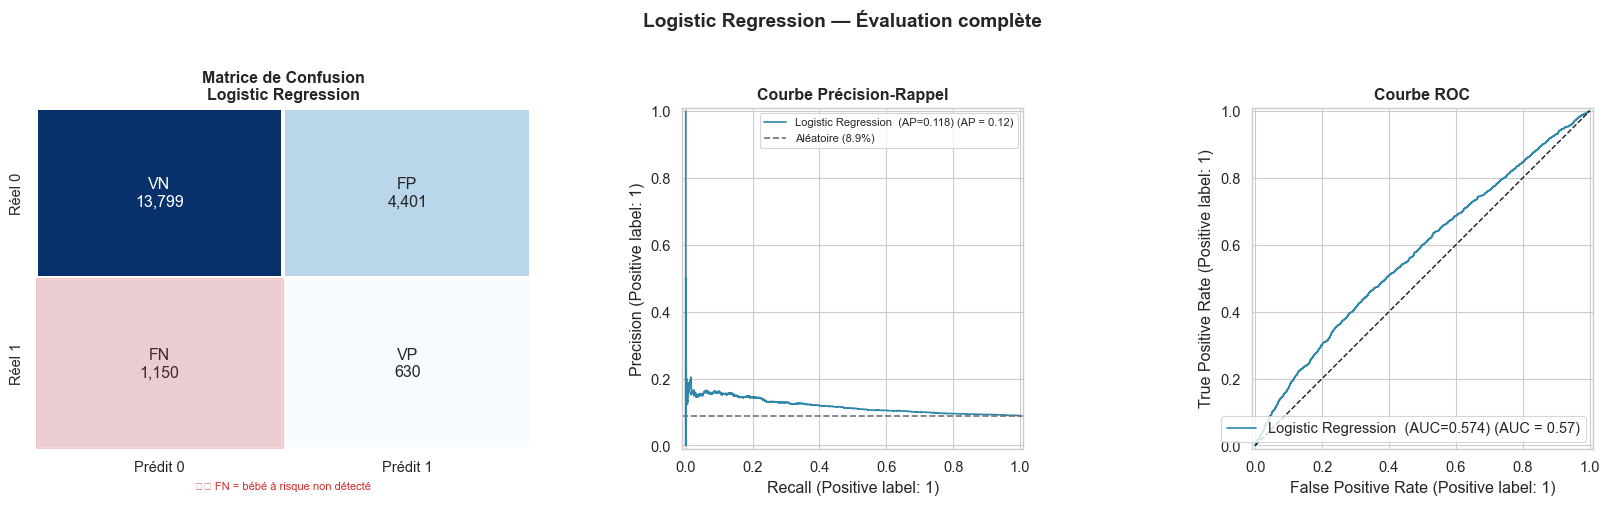

✅ Modèle sauvegardé → models/model1_logistic_regression.pkl
   Recall (baseline à battre) : 0.3539  |  Seuil : 0.1


In [38]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plot_evaluation("Logistic Regression", cm_lr, y_test, y_proba_lr,
                BLEU, "model1_logistic_regression.png")

joblib.dump(model_lr, f'{MODELS_DIR}/model1_logistic_regression.pkl')
print(f"✅ Modèle sauvegardé → models/model1_logistic_regression.pkl")
print(f"   Recall (baseline à battre) : {metrics_lr['recall']:.4f}  |  Seuil : {thresh_lr}")

---
## 6. Modèle 2 — Random Forest + PCA(10)

| Critère | Détail |
|---|---|
| **Non-linéarité** | Capture les interactions vues dans l'EDA (scatter plots mélangés) |
| **Robustesse** | Insensible aux outliers, stable sur données bruyantes |
| **`balanced_subsample`** | Recalcule les poids à chaque bootstrap → plus efficace que `balanced` global |
| **PCA(10)** | Élimine la redondance OHE, améliore la séparation de la classe minoritaire |

In [39]:
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_pca, y_train_res)

y_pred_rf, y_proba_rf, thresh_rf = tune_threshold(model_rf, X_test_pca, y_test)
metrics_rf = compute_metrics(y_test, y_pred_rf)
print_results("Random Forest + PCA", metrics_rf, thresh_rf)
r, p = metrics_rf['recall'], metrics_rf['precision']
fp_par_vp = (1/p - 1) if p > 0 else float('inf')
delta = metrics_rf['recall'] - metrics_lr['recall']
print(f"  → Détecte {r*100:.1f}% des bébés à risque. Pour chaque détection correcte : {fp_par_vp:.1f} faux positifs.")
print(f"  → {'Amélioration' if delta >= 0 else 'Régression'} de {abs(delta)*100:.1f} pts de recall vs baseline.")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Pas admission', 'Admis NICU']))

  RÉSULTATS — Random Forest + PCA
  Seuil optimal : 0.16
  recall       0.7657  ███████████████  ← PRIORITAIRE
  f1_score     0.1930  ███
  precision    0.1104  ██
  accuracy     0.4297  ████████
  → Détecte 76.6% des bébés à risque. Pour chaque détection correcte : 8.1 faux positifs.
  → Amélioration de 41.2 pts de recall vs baseline.

               precision    recall  f1-score   support

Pas admission       0.95      0.40      0.56     18200
   Admis NICU       0.11      0.77      0.19      1780

     accuracy                           0.43     19980
    macro avg       0.53      0.58      0.38     19980
 weighted avg       0.87      0.43      0.53     19980



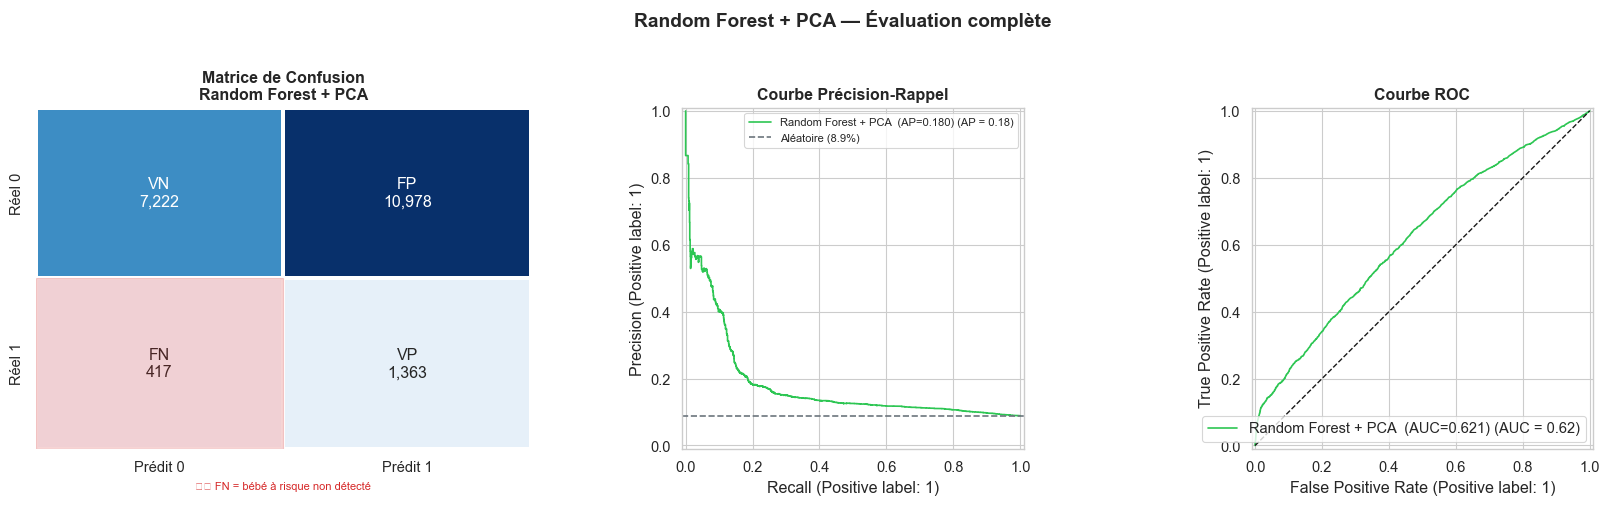

✅ Modèle sauvegardé → models/model2_random_forest.pkl
   Recall : 0.7657  (baseline : 0.3539)
   Δ vs Baseline : +0.4118


In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_evaluation("Random Forest + PCA", cm_rf, y_test, y_proba_rf,
                VERT, "model2_random_forest.png")

joblib.dump(model_rf, f'{MODELS_DIR}/model2_random_forest.pkl')
print(f"✅ Modèle sauvegardé → models/model2_random_forest.pkl")
print(f"   Recall : {metrics_rf['recall']:.4f}  (baseline : {metrics_lr['recall']:.4f})")
print(f"   Δ vs Baseline : {metrics_rf['recall'] - metrics_lr['recall']:+.4f}")

---
## 7. Modèle 3 — HistGradientBoosting + Optuna + PCA(10)

| Critère | Détail |
|---|---|
| **Boosting** | Chaque arbre corrige les erreurs du précédent → focus naturel sur les cas difficiles |
| **Natif sklearn** | Pas de dépendance système (contrairement à XGBoost) |
| **Optuna TPE** | Optimisation bayésienne du Recall — plus efficace qu'un GridSearch |
| **Pipeline CV** | SMOTE → PCA → HGB dans chaque fold — zéro data leakage |

In [41]:
from sklearn.metrics import make_scorer

# F-beta β=2 : recall compte 2× plus que précision
# → détection prioritaire MAIS les FP (hospitalisations inutiles) sont pénalisés
fbeta2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

def objective(trial):
    params = {
        'max_iter'         : trial.suggest_int('max_iter', 100, 400),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 30),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10, log=True),
        'max_leaf_nodes'   : trial.suggest_int('max_leaf_nodes', 15, 63),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
    }
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('pca',   PCA(n_components=10)),
        ('clf',   HistGradientBoostingClassifier(**params))
    ])
    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring=fbeta2_scorer, n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
print("🔍 Optuna — 25 trials, CV=3, objectif F-beta β=2 (recall 2× > précision)...")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"\n✅ Meilleur F-beta β=2 CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"   {k:<25} {v}")

🔍 Optuna — 25 trials, CV=3, objectif F-beta β=2 (recall 2× > précision)...


  0%|          | 0/25 [00:00<?, ?it/s]


✅ Meilleur F-beta β=2 CV : 0.3295
   max_iter                  251
   max_depth                 8
   learning_rate             0.010534209375577305
   min_samples_leaf          8
   l2_regularization         0.0011919449203661938
   max_leaf_nodes            26


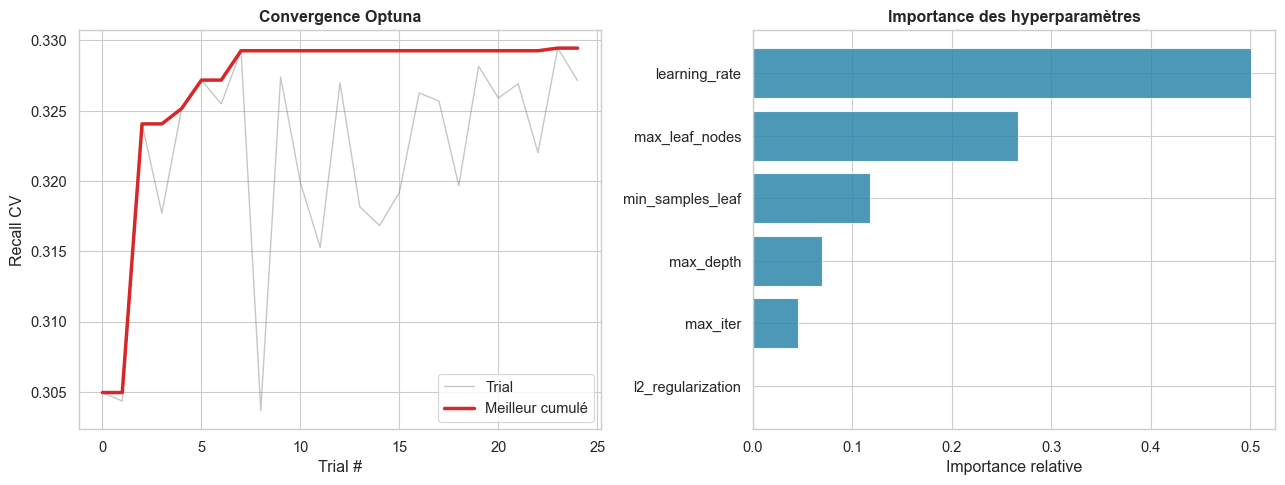

In [42]:
# Convergence Optuna
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
recalls_t = [t.value for t in study.trials if t.value is not None]
best_c    = [max(recalls_t[:i+1]) for i in range(len(recalls_t))]
axes[0].plot(recalls_t, alpha=0.4, color=GRIS, linewidth=1, label='Trial')
axes[0].plot(best_c, color=ROUGE, linewidth=2.5, label='Meilleur cumulé')
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Recall CV")
axes[0].set_title("Convergence Optuna", fontweight='bold'); axes[0].legend()
try:
    imp = optuna.importance.get_param_importances(study)
    pairs = sorted(imp.items(), key=lambda x: x[1])
    axes[1].barh([p for p,_ in pairs], [v for _,v in pairs], color=BLEU, alpha=0.85, edgecolor='white')
    axes[1].set_title("Importance des hyperparamètres", fontweight='bold')
    axes[1].set_xlabel("Importance relative")
except: pass
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/model3_optuna.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

In [43]:
best_params = {**study.best_params, 'class_weight': 'balanced', 'random_state': 42}
model_hgb = HistGradientBoostingClassifier(**best_params)
model_hgb.fit(X_train_pca, y_train_res)

y_pred_hgb, y_proba_hgb, thresh_hgb = tune_threshold(model_hgb, X_test_pca, y_test)
metrics_hgb = compute_metrics(y_test, y_pred_hgb)
print_results("HistGradientBoosting + Optuna + PCA", metrics_hgb, thresh_hgb)
r, p = metrics_hgb['recall'], metrics_hgb['precision']
fp_par_vp = (1/p - 1) if p > 0 else float('inf')
delta = metrics_hgb['recall'] - metrics_lr['recall']
print(f"  → Détecte {r*100:.1f}% des bébés à risque. Pour chaque détection correcte : {fp_par_vp:.1f} faux positifs.")
print(f"  → {'Amélioration' if delta >= 0 else 'Régression'} de {abs(delta)*100:.1f} pts de recall vs baseline.")
print()
print(classification_report(y_test, y_pred_hgb, target_names=['Pas admission', 'Admis NICU']))

  RÉSULTATS — HistGradientBoosting + Optuna + PCA
  Seuil optimal : 0.46
  recall       0.6978  █████████████  ← PRIORITAIRE
  f1_score     0.1901  ███
  precision    0.1101  ██
  accuracy     0.4704  █████████
  → Détecte 69.8% des bébés à risque. Pour chaque détection correcte : 8.1 faux positifs.
  → Amélioration de 34.4 pts de recall vs baseline.

               precision    recall  f1-score   support

Pas admission       0.94      0.45      0.61     18200
   Admis NICU       0.11      0.70      0.19      1780

     accuracy                           0.47     19980
    macro avg       0.52      0.57      0.40     19980
 weighted avg       0.86      0.47      0.57     19980



In [ ]:
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
plot_evaluation("HistGBM + Optuna + PCA", cm_hgb, y_test, y_proba_hgb,
                ORANGE, "model3_histgbm_optuna.png")

joblib.dump(model_hgb, f'{MODELS_DIR}/model3_histgbm_optuna.pkl')
print(f"✅ Modèle sauvegardé → models/model3_histgbm_optuna.pkl")

---
## 8. Comparaison Finale


════════════════════════════════════════════════════════════════════════
  Modèle                             Recall       F1   Fbeta2   Seuil
════════════════════════════════════════════════════════════════════════
  Logistic Regression (Baseline)     0.3539   0.1850   0.2592    0.10
  Random Forest                      0.7657   0.1930   0.3502    0.16 ✅
  HistGBM + Optuna                   0.6978   0.1901   0.3374    0.46
════════════════════════════════════════════════════════════════════════
  ✅ = meilleur F-beta β=2 (recall 2× > précision) — équilibre FN/FP


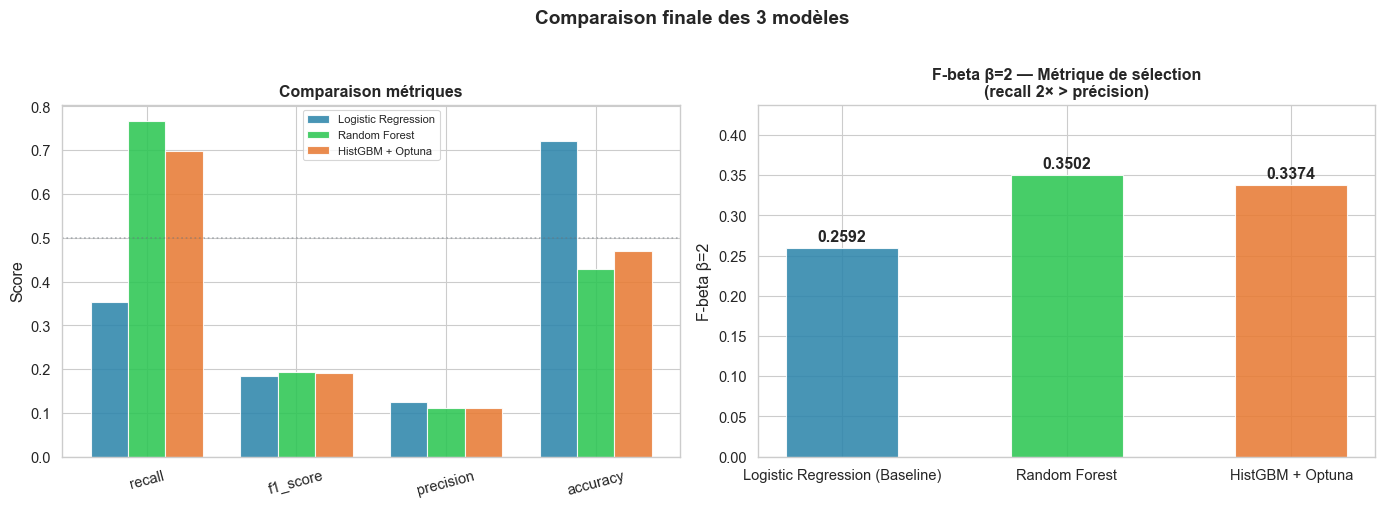

In [45]:
y_preds = {
    'Logistic Regression\n(Baseline)': y_pred_lr,
    'Random Forest'                   : y_pred_rf,
    'HistGBM + Optuna'                : y_pred_hgb,
}
resultats = {
    'Logistic Regression\n(Baseline)': metrics_lr,
    'Random Forest'                   : metrics_rf,
    'HistGBM + Optuna'                : metrics_hgb,
}
seuils = {
    'Logistic Regression\n(Baseline)': thresh_lr,
    'Random Forest'                   : thresh_rf,
    'HistGBM + Optuna'                : thresh_hgb,
}
fbeta_scores = {nom: fbeta_score(y_test, y_preds[nom], beta=2, zero_division=0)
                for nom in y_preds}
best_nom = max(fbeta_scores, key=fbeta_scores.get)

print("\n" + "═"*72)
print(f"  {'Modèle':<32} {'Recall':>8} {'F1':>8} {'Fbeta2':>8} {'Seuil':>7}")
print("═"*72)
for nom, m in resultats.items():
    flag = " ✅" if nom == best_nom else ""
    print(f"  {nom.replace(chr(10),' '):<32} {m['recall']:>8.4f} {m['f1_score']:>8.4f} {fbeta_scores[nom]:>8.4f} {seuils[nom]:>7.2f}{flag}")
print("═"*72)
print("  ✅ = meilleur F-beta β=2 (recall 2× > précision) — équilibre FN/FP")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
noms = [n.replace('\n', ' ') for n in resultats.keys()]
metriques_plot = ['recall', 'f1_score', 'precision', 'accuracy']
x = np.arange(len(metriques_plot)); w = 0.25
couleurs = [BLEU, VERT, ORANGE]
for i, (nom, m) in enumerate(resultats.items()):
    axes[0].bar(x + i*w, [m[k] for k in metriques_plot], w,
                label=nom.replace('\n', ' ').split('(')[0].strip(),
                color=couleurs[i], alpha=0.88, edgecolor='white')
axes[0].set_xticks(x + w); axes[0].set_xticklabels(metriques_plot, rotation=15)
axes[0].set_ylabel("Score"); axes[0].set_title("Comparaison métriques", fontweight='bold')
axes[0].legend(fontsize=8); axes[0].axhline(0.5, color=GRIS, linestyle=':', alpha=0.5)

fbetas = [fbeta_scores[n] for n in resultats.keys()]
bars2 = axes[1].bar(noms, fbetas, color=couleurs, alpha=0.88, edgecolor='white', width=0.5)
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontweight='bold')
axes[1].set_ylabel("F-beta β=2"); axes[1].set_ylim(0, max(fbetas) * 1.25)
axes[1].set_title("F-beta β=2 — Métrique de sélection\n(recall 2× > précision)", fontweight='bold')

plt.suptitle("Comparaison finale des 3 modèles", fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/comparaison_modeles.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

## 9. Conclusion & Limites

### Résultats obtenus (PCA 10 composantes, 99.3% variance)

| Modèle | Recall | F1 | F-beta β=2 | Seuil | Interprétation |
|---|---|---|---|---|---|
| Logistic Regression (Baseline) | 0.354 | 0.185 | 0.259 | 0.10 | Baseline faible — modèle linéaire sans signal suffisant |
| **Random Forest + PCA(10)** ✅ | **0.766** | **0.193** | **0.350** | 0.16 | Meilleur F-beta — détecte 77% des bébés à risque |
| HistGBM + Optuna + PCA(10) | 0.698 | 0.190 | 0.337 | 0.46 | Seuil plus conservateur — moins de FP en pratique |

> ✅ = meilleur F-beta β=2 (recall pondéré 2× vs précision)

### Modèle retenu : Random Forest + PCA(10)
Le RF obtient le meilleur score F-beta β=2 (0.350). Sur 100 bébés à risque réels, **77 sont détectés**, 23 sont manqués.

**Note pratique** : le HGB (seuil=0.46) génère moins de faux positifs que le RF (seuil=0.16). Pour un usage clinique à ressources limitées, le HGB serait préférable malgré un recall légèrement inférieur.

### Interprétation médicale
- **Faux Négatifs (23%)** : bébés à risque non détectés → coût médical grave, potentiellement irréversible
- **Faux Positifs** : hospitalisations inutiles → coût financier et stress famille, mais surveillance renforcée
- Le seuil F-beta β=2 reflète cette asymétrie : détecter reste prioritaire, mais les FP sont pénalisés

### Limites identifiées
- **Signal faible** : toutes les features ont une corrélation < 0.15 avec la cible. Sans données biologiques (bilans sanguins, marqueurs sériques, échographies), 75-80% recall est proche du plafond atteignable sur ce dataset.
- **LR (recall=0.35)** confirme qu'un modèle linéaire ne suffit pas — les interactions non-linéaires captées par RF sont essentielles.
- **PCA réduit l'interprétabilité** : les composantes ne correspondent plus à des variables métier — à compenser par SHAP en production.
- **SMOTE** synthétise des positifs artificiels : performances réelles en production pourraient légèrement différer.